# Парсинг логов скрипта мониторинга

Парсим логи скрипта, мониторящего потребление памяти топ 10 (или скольки-то еще) процессов

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
logdir='../var/log/tinymonitor/proc'
print(logdir)

../var/log/tinymonitor/proc


In [46]:
df = pd.read_csv(os.path.join(logdir,'2025-10-02_worker_tinymonitor.csv'), sep='|')
display(df.head())
# print(df.info())

,NUM,DATE,TIME,HOST,PID,PPID,RSS(MB),VSZ(MB),MEM,CPU,MAXMAPCOUNT,MAPS,BALLOON,CMD
0,1,2025-10-02,00:00:01,worker,2000221,1999283,2448,13219,15.3,7.1,65530,1843,0 MB,/usr/local/bin/python3.12
1,2,2025-10-02,00:00:01,worker,2000164,1999200,1328,5269,8.3,0.8,65530,1840,0 MB,/usr/local/bin/python3.12
2,3,2025-10-02,00:00:01,worker,1999640,1999599,683,4193,4.2,8.3,65530,1811,0 MB,/usr/local/bin/python3.12
3,4,2025-10-02,00:00:01,worker,1838,786,470,4201,2.9,0.0,65530,282,0 MB,/opt/drweb.com/bin/drweb-se.real
4,5,2025-10-02,00:00:01,worker,2337293,1838,451,4201,2.8,1.7,65530,281,0 MB,/opt/drweb.com/bin/drweb-se.real


In [8]:
df2 = df.copy()
df2['datetime'] = (df['DATE'] + ' ' + df['TIME']).astype('datetime64')
df2 = df2.drop(['BALLOON', 'CMD'], axis=1)
display(df2.head())
print(df2.info())

,NUM,DATE,TIME,HOST,PID,PPID,RSS(MB),VSZ(MB),%MEM,%CPU,MMC,MAPS,datetime
0,1,2025-08-12,12:42:01,host,529413,529393,1685,7841,10.5,0.3,65530,483,2025-08-12 12:42:01
1,2,2025-08-12,12:42:01,host,1836985,1836472,1030,4191,6.4,0.2,65530,434,2025-08-12 12:42:01
2,3,2025-08-12,12:42:01,host,2135589,2135568,994,5767,6.2,1.1,65530,460,2025-08-12 12:42:01
3,4,2025-08-12,12:42:01,host,1838285,1836391,788,4208,4.9,0.1,65530,785,2025-08-12 12:42:01
4,5,2025-08-12,12:42:01,host,674860,674837,772,7812,4.8,0.2,65530,471,2025-08-12 12:42:01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   NUM       130 non-null    int64         
 1   DATE      130 non-null    object        
 2   TIME      130 non-null    object        
 3   HOST      130 non-null    object        
 4   PID       130 non-null    int64         
 5   PPID      130 non-null    int64         
 6   RSS(MB)   130 non-null    int64         
 7   VSZ(MB)   130 non-null    int64         
 8   %MEM      130 non-null    float64       
 9   %CPU      130 non-null    float64       
 10  MMC       130 non-null    int64         
 11  MAPS      130 non-null    int64         
 12  datetime  130 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(7), object(3)
memory usage: 13.3+ KB
None


In [9]:
df3 = df2[df2['PID'] == 529413].set_index('datetime')
df3.resample('1H').mean()

,NUM,PID,PPID,RSS(MB),VSZ(MB),%MEM,%CPU,MMC,MAPS
datetime,,,,,,,,,
2025-08-12 12:00:00,1.0,529413.0,529393.0,1685.0,7841.0,10.5,0.3,65530.0,483.0


In [10]:
df3.head()

,NUM,DATE,TIME,HOST,PID,PPID,RSS(MB),VSZ(MB),%MEM,%CPU,MMC,MAPS
datetime,,,,,,,,,,,,
2025-08-12 12:42:01,1,2025-08-12,12:42:01,host,529413,529393,1685,7841,10.5,0.3,65530,483
2025-08-12 12:43:01,1,2025-08-12,12:43:01,host,529413,529393,1685,7841,10.5,0.3,65530,483
2025-08-12 12:44:01,1,2025-08-12,12:44:01,host,529413,529393,1685,7841,10.5,0.3,65530,483
2025-08-12 12:45:01,1,2025-08-12,12:45:01,host,529413,529393,1685,7841,10.5,0.3,65530,483
2025-08-12 12:46:01,1,2025-08-12,12:46:01,host,529413,529393,1685,7841,10.5,0.3,65530,483


In [22]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13 entries, 2025-08-12 12:42:01 to 2025-08-12 12:54:01
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   NUM      13 non-null     int64  
 1   DATE     13 non-null     object 
 2   TIME     13 non-null     object 
 3   HOST     13 non-null     object 
 4   PID      13 non-null     int64  
 5   PPID     13 non-null     int64  
 6   RSS(MB)  13 non-null     int64  
 7   VSZ(MB)  13 non-null     int64  
 8   %MEM     13 non-null     float64
 9   %CPU     13 non-null     float64
 10  MMC      13 non-null     int64  
 11  MAPS     13 non-null     int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 1.3+ KB


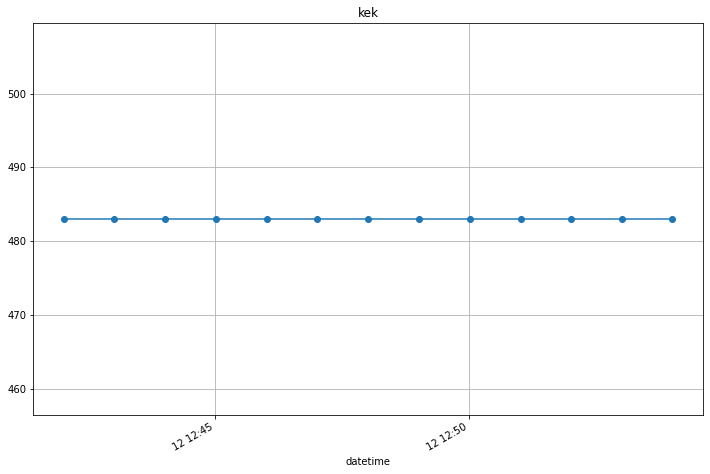

In [27]:
df3['MAPS'].plot(style='-o'
       , grid=True
       , title='kek'
       , figsize=(12, 8))
plt.show()

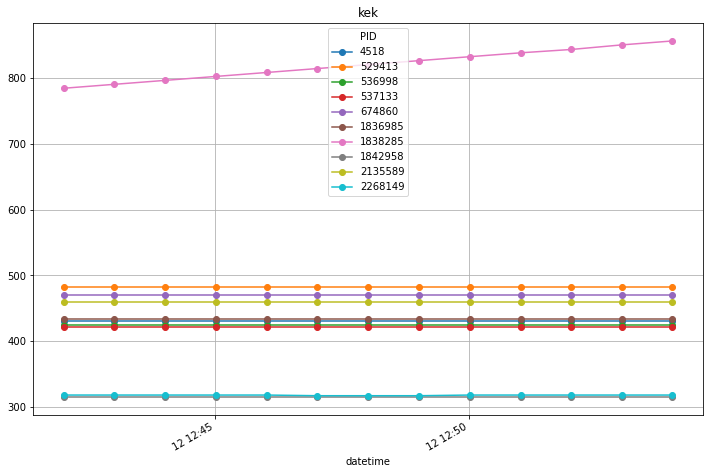

In [39]:
df2.pivot_table(index='datetime', columns='PID', values='MAPS').plot(style='-o'
       , grid=True
       , title='kek'
       , figsize=(12, 8))
plt.show()

In [37]:
df4=df2.pivot_table(index='datetime', columns='PID', values='MAPS')

In [38]:
df4.head()

PID,4518,529413,536998,537133,674860,1836985,1838285,1842958,2135589,2268149
datetime,,,,,,,,,,
2025-08-12 12:42:01,430,483,424,421,471,434,785,315,460,318
2025-08-12 12:43:01,430,483,424,421,471,434,791,315,460,318
2025-08-12 12:44:01,430,483,424,421,471,434,797,315,460,318
2025-08-12 12:45:01,430,483,424,421,471,434,803,315,460,318
2025-08-12 12:46:01,430,483,424,421,471,434,809,315,460,318


In [62]:
import re
import glob
import os.path
import pandas as pd
from typing import Literal, List
from datetime import datetime, timedelta



def filter_recent_files(files: List[str], seconds: int) -> List[str]:
    """
    Фильтрует список файлов, оставляя только те, что не старше (текущего времени - seconds - 24 часа).
    Предполагается, что имя файла начинается с даты в формате 'YYYY-MM-DD'.
    
    :param files: список строк с именами файлов
    :param seconds: количество секунд для фильтрации
    :return: отфильтрованный список файлов
    """
    now = datetime.now()
    cutoff = now - timedelta(seconds=seconds) - timedelta(hours=24)

    filtered_files = []

    for file in files:
        # Ищем дату в начале имени файла
        filename = os.path.basename(file)
        abspath = os.path.abspath(file)
        match = re.match(r"^(\d{4}-\d{2}-\d{2})", filename)
        if match:
            try:
                file_date = datetime.strptime(match.group(1), "%Y-%m-%d")
                if file_date >= cutoff:
                    filtered_files.append(abspath)
            except ValueError:
                # Пропускаем, если дата некорректная
                continue

    return filtered_files


def read_log_files(directory: str, format: Literal["csv", "json"], range: int):
    """
    Считывает все файлы формата csv или json из директории, 
        - объединяет
        - фильтрует по времени
        - отрезает в рамках интервала 
        - преобразует в большой json.

    :param directory: путь к директории с файлами
    :param format: "csv" или "json"
    :param range: интервал в секундах
    :return: объединённый json
    """

    if not os.path.isdir(directory):
        print(os.path.abspath(directory))
        raise FileNotFoundError(f"Директория не найдена: {directory}")
    
    response = '[{"cpu":"","mem":"","timestamp":"","pid":""}]'
    file_path_list = glob.glob(os.path.join(directory, "*."+format))
    if not file_path_list:
        print("Файлы не найдены.")
        return response
    else:
#         print("full file path list:", file_path_list)
        file_path_list = filter_recent_files(file_path_list, range)
#         print("filtered list:", file_path_list)
        if not file_path_list:
            return response

    now = datetime.now()
    cutoff = now - timedelta(seconds=range)
    dataframe = []

    for file in file_path_list:
        try:
            if format == "csv":
                df = pd.read_csv(file, delimiter="|")
            else:
                df = pd.read_json(file)
        except Exception as e:
            print(f"Ошибка при чтении файла {file}: {e}")

        df['timestamp'] = (df['DATE'] + ' ' + df['TIME']).astype('datetime64[ns]')
        df = df[["timestamp", "CPU", "MEM", "PID", "HOST"]]
        df = df[(df["timestamp"] >= cutoff)]
        dataframe.append(df)

    df=pd.concat(dataframe, axis=0)
#     print(df.info())
    if len(df) > 0:
        df.sort_values("timestamp", inplace=True)
        response = df.to_dict(orient="records")
        
    return df

In [64]:
df=read_log_files(logdir, 'csv', 390000)
display(df.head())
display(df.tail())

,timestamp,CPU,MEM,PID,HOST
4890,2025-10-02 08:09:01,3.5,15.3,2000221,worker
4891,2025-10-02 08:09:01,0.4,8.3,2000164,worker
4892,2025-10-02 08:09:01,4.2,4.2,1999640,worker
4893,2025-10-02 08:09:01,0.0,2.9,1838,worker
4894,2025-10-02 08:09:01,0.8,2.8,2586664,worker


,timestamp,CPU,MEM,PID,HOST
5924,2025-10-02 09:52:01,0.8,2.8,2618134,worker
5925,2025-10-02 09:52:01,0.8,2.8,2618125,worker
5926,2025-10-02 09:52:01,0.8,2.8,2618139,worker
5927,2025-10-02 09:52:01,0.8,2.8,2618146,worker
5929,2025-10-02 09:52:01,0.1,2.0,1999886,worker


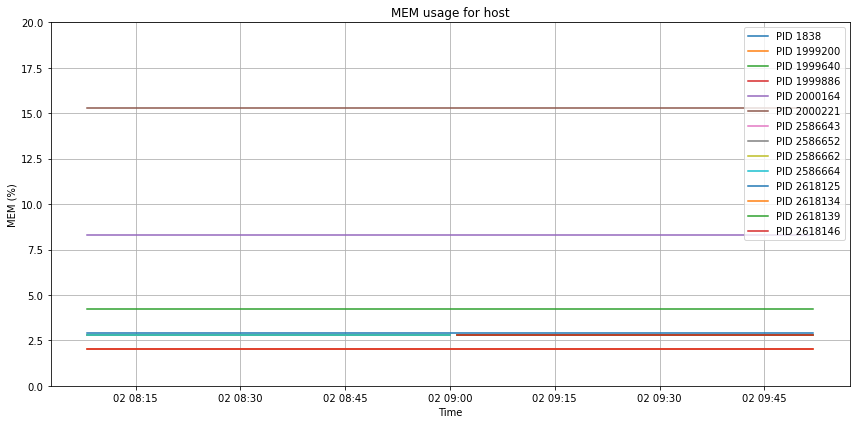

In [60]:
# Настройка графика
plt.figure(figsize=(12, 6))  # фиксированный размер графика
plt.ylim(0, 20)             # ось Y от 0 до 100 (проценты)

# Отрисовка CPU по каждому PID
for pid, group in df.groupby('PID'):
    plt.plot(group['timestamp'], group['MEM'], label=f'PID {pid}')

# Подписи и оформление
plt.title(f"MEM usage for host")
plt.xlabel("Time")
plt.ylabel("MEM (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()